In [5]:
import warnings
import math

from IPython.display import display, HTML, SVG

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import neutcurve
from neutcurve.colorschemes import CBPALETTE
from neutcurve.colorschemes import CBMARKERS

from plotnine import *

import yaml

print(f"Using `neutcurve` version {neutcurve.__version__}")

Using `neutcurve` version 2.1.0


In [6]:
warnings.simplefilter('ignore')
theme_set(theme_seaborn(style='white', context='talk', font_scale=1))

In [7]:
import matplotlib as mpl
from contextlib import contextmanager

@contextmanager
def publication_svg_style():
    original_rcParams = mpl.rcParams.copy()
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['axes.linewidth'] = 0.5
    mpl.rcParams['xtick.major.width'] = 0.5
    mpl.rcParams['ytick.major.width'] = 0.5
    mpl.rcParams['xtick.minor.width'] = 0.5
    mpl.rcParams['ytick.minor.width'] = 0.5
    mpl.rcParams['lines.linewidth'] = 0.5
    mpl.rcParams['lines.markersize'] = 4
    mpl.rcParams['lines.markeredgecolor'] = 'auto'
    mpl.rcParams['lines.markeredgewidth'] = 0.25
    mpl.rcParams['legend.edgecolor'] = 'none'
    try:
        yield
    finally:
        mpl.rcParams.update(original_rcParams)

def format_neutcurve_axes(axes):
    if isinstance(axes, np.ndarray):
        axes_list = list(axes.flat)
    elif isinstance(axes, (list, tuple)):
        axes_list = axes
    else:
        axes_list = [axes]

    for ax in axes_list:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

        ax.tick_params(width=0.5)

        for line in ax.lines:
            line.set_linewidth(0.5)
            line.set_markeredgewidth(0.25)
            if line.get_marker() in ['_', '|']:
                line.set_markeredgewidth(0.5)

        for collection in ax.collections:
            collection.set_linewidth(0.5)

        legend = ax.get_legend()
        if legend:
            legend.get_frame().set_linewidth(0.5)

In [8]:
df = pd.read_csv('fractinfect_2.csv')


In [9]:
fits = neutcurve.curvefits.CurveFits(
            data=df,
            fixbottom=0,
            )

fitParams = fits.fitParams(ics=[10,50, 90, 95, 97, 98, 99])

In [10]:
fitParams = fits.fitParams(ics=[10,50, 90, 95, 97, 98, 99])
fits.fitParams(ics=[10,50, 90, 95, 97, 98, 99])

,serum,virus,replicate,nreplicates,ic10,ic10_bound,ic10_str,ic50,ic50_bound,ic50_str,...,ic99_bound,ic99_str,midpoint,midpoint_bound,midpoint_bound_type,slope,top,bottom,r2,rmsd
0,hSerum_4,wild-type,average,2,0.000013,interpolated,1.28e-05,0.000169,interpolated,0.000169,...,lower,>0.025,0.000169,0.000169,interpolated,0.852155,1.0,0.0,0.985325,0.043737
1,hSerum_4,T267Y,average,2,0.000122,interpolated,0.000122,0.000659,interpolated,0.000659,...,interpolated,0.0225,0.000659,0.000659,interpolated,1.301468,1.0,0.0,0.988218,0.046223
2,hSerum_4,K65A,average,2,0.000045,interpolated,4.5e-05,0.000367,interpolated,0.000367,...,lower,>0.025,0.000367,0.000367,interpolated,1.046530,1.0,0.0,0.995132,0.027894
3,hSerum_4,S377V,average,2,0.000041,interpolated,4.13e-05,0.000340,interpolated,0.00034,...,lower,>0.025,0.000340,0.000340,interpolated,1.041354,1.0,0.0,0.991584,0.035412
4,hSerum_1,wild-type,average,2,0.000005,interpolated,5.21e-06,0.000039,interpolated,3.92e-05,...,interpolated,0.00267,0.000039,0.000039,interpolated,1.088981,1.0,0.0,0.995181,0.024208
5,hSerum_1,K68V,average,2,0.000004,upper,<3.81e-06,0.000035,interpolated,3.51e-05,...,interpolated,0.00412,0.000035,0.000035,interpolated,0.964243,1.0,0.0,0.996328,0.020073
6,hSerum_1,S215E,average,2,0.000017,interpolated,1.71e-05,0.000145,interpolated,0.000145,...,interpolated,0.0126,0.000145,0.000145,interpolated,1.029336,1.0,0.0,0.997506,0.019321
7,hSerum_1,K209N,average,2,0.000016,interpolated,1.58e-05,0.000141,interpolated,0.000141,...,interpolated,0.0138,0.000141,0.000141,interpolated,1.002619,1.0,0.0,0.997527,0.018903
8,hSerum_2,wild-type,average,2,0.000022,interpolated,2.24e-05,0.000084,interpolated,8.42e-05,...,interpolated,0.00134,0.000084,0.000084,interpolated,1.660133,1.0,0.0,0.991987,0.039142
9,hSerum_2,S180A,average,2,0.000004,upper,<3.81e-06,0.000022,interpolated,2.17e-05,...,interpolated,0.000901,0.000022,0.000022,interpolated,1.233957,1.0,0.0,0.993563,0.026351


In [11]:
fits.fitParams(ics=[10,50, 90, 95, 97, 98, 99]).to_csv("IC_values.csv")

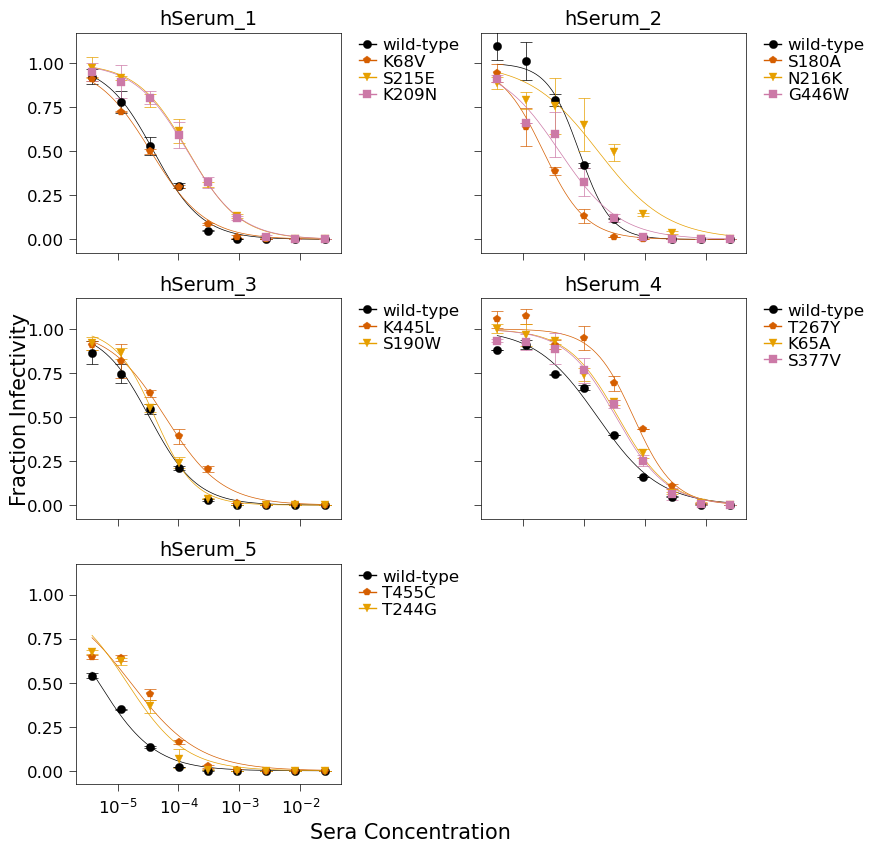

In [12]:
with publication_svg_style():
    fig,axes = fits.plotSera(
                xlabel='Sera Concentration', max_viruses_per_subplot=11,
                sera=['hSerum_1', 'hSerum_2', 'hSerum_3', 'hSerum_4', 'hSerum_5'],
                colors = ['#000000','#D55E00','#E69F00',
                                                                                        '#CC79A7','#1B7837','#56B4E9','#0072B2','#762A83','#009E73', 
                                                                                      '#000000','#F0E442', 
                                                                                        ],   
                markers = ['o', 'p', 'v', 's', 'o', '^', 'D', 's', 'v', '8', 's'],
                draw_in_bounds=True, ncol=2,
                ylabel='Fraction Infectivity'
    )

    # Make the plots wider to accommodate external legends
    fig.set_size_inches(10, 9)  # Taller for 5 sera (3 rows at ncol=2)

    # Post-process: move legends outside each subplot
    for ax in axes.flat:
        legend = ax.get_legend()
        if legend:
            # Position legend outside the right edge of each subplot
            legend.set_bbox_to_anchor((1.05, 1))
            legend.set_loc('upper left')

    # Adjust layout to accommodate external legends with wider figure
    plt.tight_layout()
    plt.subplots_adjust(right=0.80)  # Adjusted for wider figure - leave 20% for legends

    # Enforce 0.5 pt strokes on lines, error bars and caps for publication
    format_neutcurve_axes(axes)

    fig.savefig('Neut_indiv.pdf', dpi=300, bbox_inches='tight')
    fig.savefig('Neut_indiv.svg', format='svg', bbox_inches='tight')